# Add all required library
## y = 13*xs + 7 *zs -12


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
# declare variable containing size of training set
observations = 1000

# Create xs and zs of 1000x1 matrix
xs = np.random.uniform(low=-10, high=10, size=(observations, 1))
zs = np.random.uniform(low=-10, high=10, size=(observations, 1))

# Combine xs,zs into single matrix with size of 1000x2
# This is the X matrix from liner model y=X*w + b
## column_stack
inputs = np.column_stack((xs, zs))
print(f"X shape = {inputs.shape}")


X shape = (1000, 2)


# Generating target that we are aiming at

In [4]:
# We want to "make up" a function, use the ML methodology, and see if the algorithm has learned it.
# We add a small random noise to the function i.e. f(x,z) = 2x - 3z + 5 + <small noise>
noise = np.random.uniform(low=-1, high=1, size=(observations, 1))
print(f"Noise shape = {noise.shape}")
# Produce the targets according to the f(x,z) = 2x - 3z + 5 + noise definition.
# In this way, we are basically saying: the weights should be 2 and -3, while the bias is
targets = 13 * xs + 7 * zs - 12 + noise
print(f"Target shape = {targets.shape}")

Noise shape = (1000, 1)
Target shape = (1000, 1)


# Plot training data

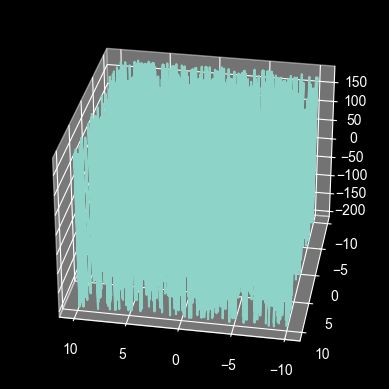

In [5]:
# In order to use the 3D plot, the objects should have a certain shape, so we reshape the targets.
# The proper method to use is reshape and takes as arguments the dimensions in which we want to fit the object.
targets = targets.reshape(observations,)
# Plotting according to the conventional matplotlib.pyplot syntax

# Declare the figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# Choose the area
ax.plot(xs,zs, targets)

# You can fiddle with the azim parameter to plot the data from different angles. Just change the value of azim=100
# to azim = 0 ; azim = 200, or whatever. Check and see what happens.
ax.view_init(azim=100)

# So far we were just describing the plot. This method actually shows the plot.
plt.show()

# We reshape the targets back to the shape that they were in before plotting.
# This reshaping is a side-effect of the 3D plot. Sorry for that.
targets = targets.reshape(observations, 1)


# Initialize variable

In [6]:
# We will initialize the weights and biases randomly in some small initial range.
# init_range is the variable that will measure that.
# You can play around with the initial range, but we don't really encourage you to do so.
# High initial ranges may prevent the machine learning algorithm from learning.
init_range = 0.1

# Weights are of size k x m, where k is the number of input variables and m is the number of output variables
# In our case, the weights matrix is 2x1 since there are 2 inputs (x and z) and one output (y)
weights = np.random.uniform(low=-init_range, high=init_range, size=(2, 1))
# Biases are of size 1 since there is only 1 output. The bias is a scalar.
biases = np.random.uniform(low=-init_range, high=init_range, size= 1)
#Print the weights to get a sense of how they were initialized.
print(weights)
print(biases)

[[-0.09013105]
 [ 0.00429195]]
[0.00752243]


# Set learning rate

In [7]:
learning_rate = 0.02

# Train model

In [8]:
# We iterate over our training dataset 100 times. That works well with a learning rate of 0.02.
# The proper number of iterations is something we will talk about later on, but generally
# a lower learning rate would need more iterations, while a higher learning rate would need less iterations
# keep in mind that a high learning rate may cause the loss to diverge to infinity, instead of converge to 0.
for i in range(100):
    # This is the linear model: y = xw + b equation
    outputs = np.dot(inputs, weights) + biases
    # The deltas are the differences between the outputs and the targets
    # Note that deltas here is a vector 1000 x 1
    deltas = outputs - targets
     # We are considering the L2-norm loss, but divided by 2, so it is consistent with the lectures.
    # Moreover, we further divide it by the number of observations.
    # This is simple rescaling by a constant. We explained that this doesn't change the optimization logic,
    # as any function holding the basic property of being lower for better results, and higher for worse results
    # can be a loss function.
    lose = np.sum(deltas**2)/2/observations
    # We print the loss function value at each step so we can observe whether it is decreasing as desired.
    print(lose)
    # Another small trick is to scale the deltas the same way as the loss function
    # In this way our learning rate is independent of the number of samples (observations).
    # Again, this doesn't change anything in principle, it simply makes it easier to pick a single learning rate
    # that can remain the same if we change the number of training samples (observations).
    # You can try solving the problem without rescaling to see how that works for you.
    deltas_scaled = deltas / observations
    # Finally, we must apply the gradient descent update rules from the relevant lecture.
    # The weights are 2x1, learning rate is 1x1 (scalar), inputs are 1000x2, and deltas_scaled are 1000x1
    # We must transpose the inputs so that we get an allowed operation.
    weights = weights - learning_rate * np.dot(inputs.T, deltas_scaled)
    biases  = biases -learning_rate * np.sum(deltas_scaled)
     # The weights are updated in a linear algebraic way (a matrix minus another matrix)
    # The biases, however, are just a single number here, so we must transform the deltas into a scalar.
    # The two lines are both consistent with the gradient descent methodology.


3592.0513925855926
543.8894457167596
129.8142922323578
71.65661281653634
61.66757891556145
58.270060034123176
55.843944147414874
53.626782489743576
51.51249973700241
49.483815922308494
47.535563690222375
45.66432401042492
43.8670215531584
42.1407306779704
40.48264514325552
38.890070095607314
37.36041722398673
35.89120049015598
34.48003207978931
33.12461852057805
31.82275695465676
30.572331558433092
29.37131010388644
28.217740655730907
27.10974839907288
26.045532592406815
25.02336364099741
24.041580285891477
23.09858690399109
22.192850914800335
21.322900289630386
20.487321159215405
19.68475551585065
18.913899006318648
18.173498812016078
17.462351612836134
16.779301631497535
16.12323875514132
15.493096731142865
14.887851434206972
14.306519201929227
13.748155236119121
13.21185206728639
12.696738079794843
12.201976095287124
11.726762012077986
11.270323498304561
10.831918736709923
10.410835219020097
10.006388587954538
9.617921524988734
9.244802682060808
8.886425655486153
8.542208000412371
8

# Print weights and biases and see if we have worked correctly.

In [9]:
print(weights)
print(biases)

[[13.00583108]
 [ 7.00886859]]
[-10.42590235]


# plot input and target

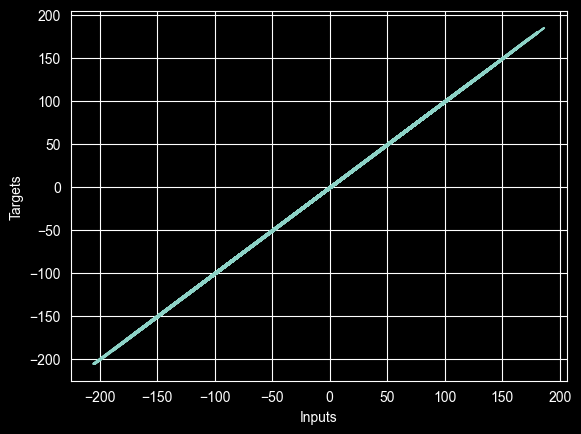

In [10]:
plt.plot(outputs, targets)
plt.xlabel("Inputs")
plt.ylabel("Targets")
plt.show()